Import libraries 

pandas is used for datamanipulation 

Numpy is used for mathematical calculation

matplotlib is used for visulalization

seaborn is used for advance statistical visulalizations

LabelEncoder is used for Convert categorical values into numbers

train_test_split is used for Split dataset into training and testing sets.

metricsis used for Measure model performance.

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load the dataset

In [25]:
df = pd.read_csv("diamonds.csv")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Check rows, columns, datatype, and missing values.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [27]:
df.shape

(53940, 10)

In [28]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

Check Missing Values

In [29]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Statistical summary

In [30]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


EDA - Exploratory Data Analysis

Distribution of Diamond Price

Histogram

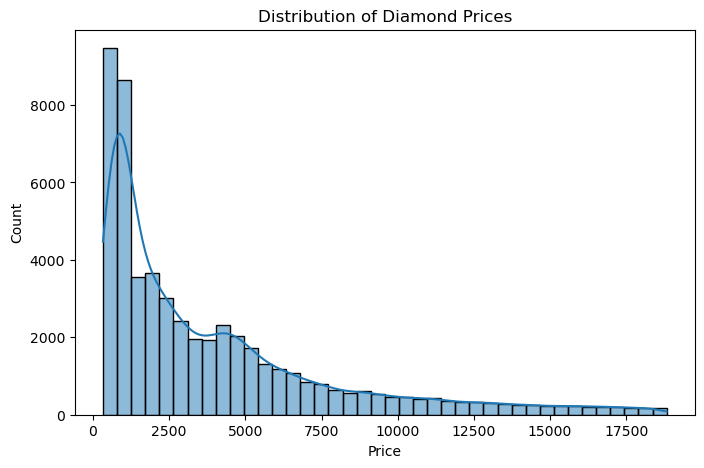

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Boxplot

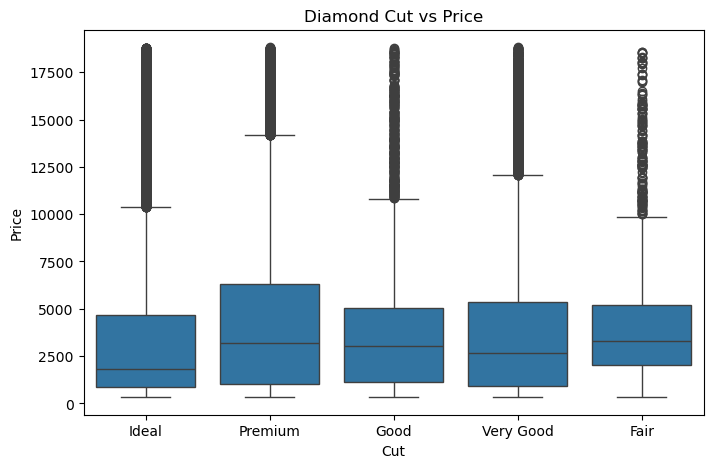

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cut", y="price", data=df)
plt.title("Diamond Cut vs Price")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

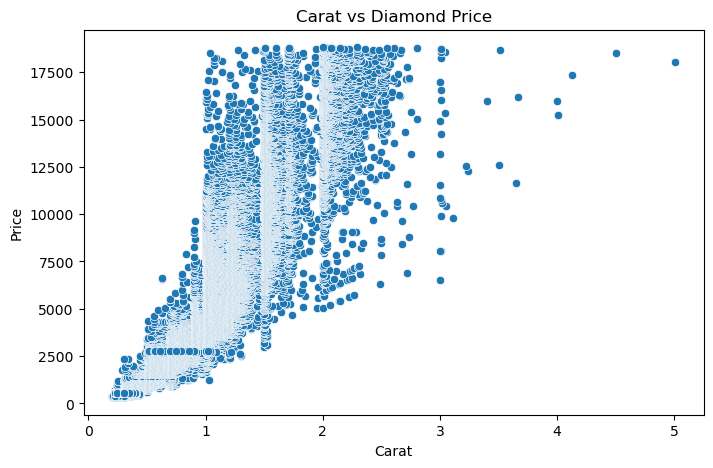

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="carat", y="price", data=df)
plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

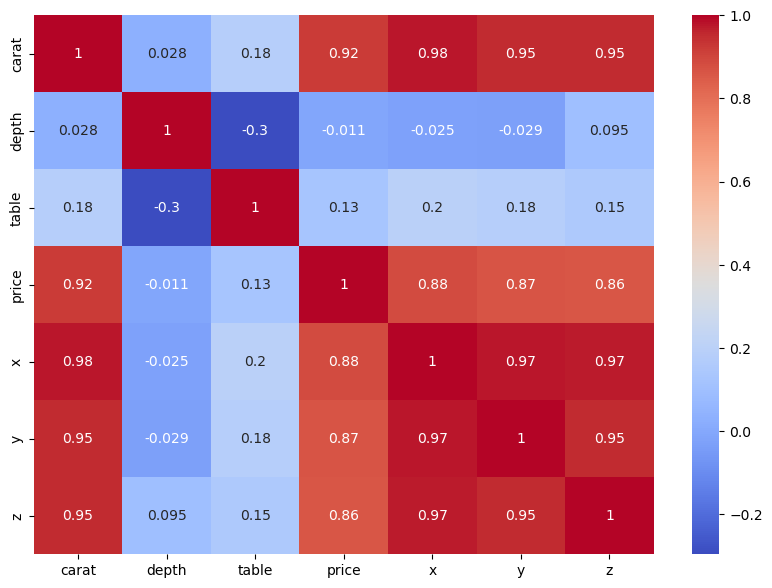

In [34]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

Machine Learning models cannot understand text values directly, so convert them into numbers.

In [35]:
encoder = LabelEncoder()

df["cut"] = encoder.fit_transform(df["cut"])

df["color"] = encoder.fit_transform(df["color"])

df["clarity"] = encoder.fit_transform(df["clarity"])

 Split Features and Target

In [36]:
X = df.drop("price", axis=1)

y = df["price"]

Split Dataset into Training and Testing

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Linear Regression Model

In [38]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict Diamond Prices

In [39]:
y_pred = lr.predict(X_test)

Evaluate Linear Regression Model




In [40]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 858.7084697710083
MSE : 1825912.9915253473
RMSE: 1351.263479683125
R2 Score: 0.8851397433679632


Compare Actual and Predicted Prices

In [41]:
results = pd.DataFrame({
    "Actual Price": y_test,

    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
1388,559,363.646688
50052,2201,3355.932308
41645,1238,2139.566064
42377,1304,2371.644610
17244,6901,10551.699188
1608,3011,5692.876770
46398,1765,1898.668082
45493,1679,2610.081088
49385,2102,3071.451463
10460,4789,5817.006690
